# Performance Analysis: Conway's Game of Life

This notebook benchmarks the Game of Life simulation across different grid sizes and processing strategies (single-process vs multiprocessing with varying worker counts). The goal is to determine the crossover point where multiprocessing becomes advantageous over single-process execution, and use this to set the `multiprocessing_threshold_cells` configuration default.


### Hardware Environment
The benchmarks below were executed on the following system:
- **CPU**: 13th Gen Intel Core i9-13950HX (32 threads @ 5.50 GHz)
- **GPU**: NVIDIA GeForce RTX 4060 Laptop GPU
- **RAM**: 32 GB
- **OS**: Ubuntu 24.04 x86_64


In [7]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Add parent directory to path so we can import libs
sys.path.append(str(Path().resolve().parent))

from libs.config import BoundaryMode, SimulationConfig

In [8]:
grid_sizes = [20, 50, 100, 200, 500, 1000]
strategies = {
    "Single Process": {"type": "single"},
    "Multiprocess (2 Workers)": {"type": "multi", "workers": 2},
    "Multiprocess (4 Workers)": {"type": "multi", "workers": 4},
    "Multiprocess (8 Workers)": {"type": "multi", "workers": 8},
    "GPU (CuPy)": {"type": "gpu"},
}

num_generations = 20
results = []

for size in grid_sizes:
    shape = (size, size)
    print(f"Benchmarking {size}x{size} (Total Cells: {size * size})")

    # Generate random initial state
    initial_grid = np.random.choice([0, 1], size=shape, p=[0.8, 0.2]).astype(np.uint8)

    for name, strategy_config in strategies.items():
        grid_copy = initial_grid.copy()

        config = SimulationConfig(boundary_mode=BoundaryMode.TOROIDAL)

        from libs.config import ComputeBackend

        if strategy_config["type"] == "single":
            config.backend = ComputeBackend.CPU
            config.multiprocessing_threshold_cells = float("inf")
        elif strategy_config["type"] == "multi":
            config.backend = ComputeBackend.CPU
            config.multiprocessing_threshold_cells = 0
            config.n_workers = strategy_config["workers"]
        elif strategy_config["type"] == "gpu":
            config.backend = ComputeBackend.GPU

        from libs.parallel.dispatch import get_dispatcher

        try:
            dispatcher = get_dispatcher(shape, config, grid_copy)
        except Exception as e:
            print(f"Skipping {name} due to error: {e}")
            continue

        # Warmup
        dispatcher.step(grid_copy)

        # Benchmark
        start_ns = time.perf_counter_ns()
        for _ in range(num_generations):
            _, _, _ = dispatcher.step(grid_copy)
        end_ns = time.perf_counter_ns()

        dispatcher.shutdown()

        mean_time_ms = ((end_ns - start_ns) / 1_000_000.0) / num_generations

        results.append(
            {
                "Grid Size": size,
                "Total Cells": size * size,
                "Strategy": name,
                "Mean Time (ms)": mean_time_ms,
            }
        )
        print(f"  {name}: {mean_time_ms:.2f} ms / gen")

df = pd.DataFrame(results)

Benchmarking 20x20 (Total Cells: 400)
  Single Process: 0.04 ms / gen
  Multiprocess (2 Workers): 0.58 ms / gen
  Multiprocess (4 Workers): 1.57 ms / gen
  Multiprocess (8 Workers): 0.97 ms / gen
  GPU (CuPy): 0.26 ms / gen
Benchmarking 50x50 (Total Cells: 2500)
  Single Process: 0.06 ms / gen
  Multiprocess (2 Workers): 0.56 ms / gen
  Multiprocess (4 Workers): 1.24 ms / gen
  Multiprocess (8 Workers): 1.71 ms / gen
  GPU (CuPy): 0.27 ms / gen
Benchmarking 100x100 (Total Cells: 10000)
  Single Process: 0.16 ms / gen
  Multiprocess (2 Workers): 0.86 ms / gen
  Multiprocess (4 Workers): 1.20 ms / gen
  Multiprocess (8 Workers): 1.24 ms / gen
  GPU (CuPy): 0.31 ms / gen
Benchmarking 200x200 (Total Cells: 40000)
  Single Process: 0.47 ms / gen
  Multiprocess (2 Workers): 1.80 ms / gen
  Multiprocess (4 Workers): 1.38 ms / gen
  Multiprocess (8 Workers): 1.06 ms / gen
  GPU (CuPy): 0.25 ms / gen
Benchmarking 500x500 (Total Cells: 250000)
  Single Process: 2.34 ms / gen
  Multiprocess (2 Wo

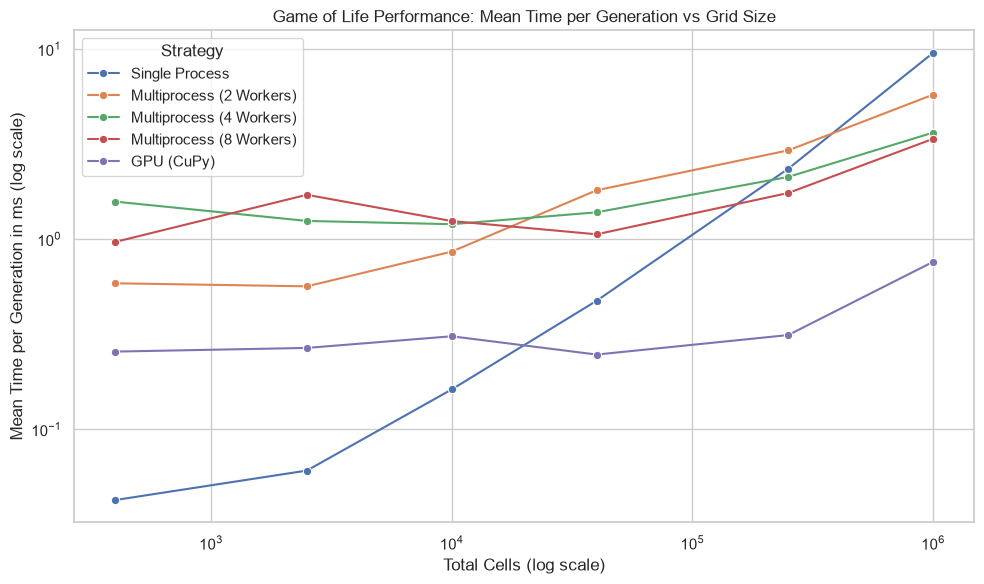

In [9]:
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x="Total Cells", y="Mean Time (ms)", hue="Strategy", marker="o")

plt.xscale("log")
plt.yscale("log")
plt.title("Game of Life Performance: Mean Time per Generation vs Grid Size")
plt.xlabel("Total Cells (log scale)")
plt.ylabel("Mean Time per Generation in ms (log scale)")
plt.legend(title="Strategy")
plt.tight_layout()
plt.show()

## Conclusion

Based on the generated plot, we can observe the crossover point where multiprocessing overhead is overcome by parallel speedup. This value should be updated in `config.yaml` / `config.py` as the `multiprocessing_threshold_cells` value, and noted in `context.md`.